# Calibrating kicker to turn by turn data

In [1]:
import xarray as xr
import numpy as np
import numpy.ma as ma
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

ModuleNotFoundError: No module named 'xarray'

In [2]:
import datetime

In [3]:
from sklearn.linear_model import LinearRegression

In [4]:
!ls;

da_aperture_analysis_lifetime.ipynb
da_aperture_analysis_tests.ipynb
da_aperture_tune_shift2.ipynb
da_aperture_tune_shift.ipynb
da_aperture_tune_shift_plots.ipynb
da_aperture_tune_shift_run_step2.ipynb
da_aperture_tune_shift_run_step.ipynb
da_constuct_iterator.ipynb
da_scan
da_scan_7595bcb8-d56d-421c-86eb-89c47ef20859.nc
da_scan_7a9bdcba-5a0d-454b-8edd-3c99bc65cc50.nc
da_scan_9d77b30d-98bb-4b03-99e4-d9b436a6868f.nc
da_scan_data_read.ipynb
da_scan_fit_x_3D.png
da_scan_fit_x.png
da_scan_plot.py
da_scan_sextupole_strenght.ipynb
da_scan_wo_harm_sext
da_scan_x.png
da_scan_x_shift.png
da_scan_y_fit_3D.png
da_scan_y_fit.png
da_scan_y.png
da_scan_y_shift.png
dt_kicker_analyse.ipynb
kicker_calibration.ipynb
kicker_calibration_preprocessed_extended2.nc
kicker_calibration_preprocessed_extended.nc
kicker_calibration_preprocessed_extended_start.nc
kicker_calibration_preprocessed.nc
kicker_data_export.ipynb
kicker_turn_by_turn_all_rays.nc
kicker_turn_by_turn_calibration_extended_range.nc
kicker_turn

In [5]:
db_filename = 'processed_da_scans_run_step.nc'

In [6]:
all_set = xr.open_dataset(db_filename)

In [7]:
all_set

<xarray.Dataset>
Dimensions:     (data: 5, harmonics: 2, plane: 2, pos: 7, run: 100, step: 102, turn: 5)
Coordinates:
  * step        (step) int32 0 1 2 3 4 5 6 7 8 ... 93 94 95 96 97 98 99 100 101
  * run         (run) int32 0 1 2 3 4 5 6 7 8 9 ... 91 92 93 94 95 96 97 98 99
  * pos         (pos) object 'x' 'y' 'r' 'phi' 'kick_x' 'kick_y' 'current'
  * data        (data) object 'order' 'frequency' 'amplitude' 'real' 'imag'
  * turn        (turn) int32 0 1 2 3 4
  * harmonics   (harmonics) object 'main' 'second'
  * plane       (plane) object 'x' 'y'
Data variables:
    excitation  (run, step, pos) float64 ...
    tune        (run, step, plane, turn, harmonics, data) float64 ...

In [8]:
nm2mm = (1e3/1e9)

In [9]:
plot_data = all_set.loc[dict(harmonics='main', data='frequency', step=all_set.coords['step'][1::])]

In [10]:
plot_pos =  plot_data.excitation

In [11]:
kick_x_p = ma.masked_array(plot_pos.loc[dict(pos='kick_x')].values.ravel(), ) * nm2mm
kick_y_p = ma.masked_array(plot_pos.loc[dict(pos='kick_y')].values.ravel(), ) * nm2mm

r_p = np.sqrt(kick_x_p**2 + kick_y_p**2)
phi_p = np.arctan2(kick_y_p, kick_x_p)

if False:
    max_index = 10 * 1000
    ref_tune_p = ref_tune_p[:max_index]
    tune_p = tune_p[:max_index]
    phi_p = phi_p[:max_index]
    r_p = r_p[:max_index]
    
x_p = ma.masked_array(plot_pos.loc[dict(pos='x')].values.ravel(), )
y_p = ma.masked_array(plot_pos.loc[dict(pos='y')].values.ravel(), )    
current = ma.masked_array(plot_pos.loc[dict(pos='current')].values.ravel(), )

In [ ]:
kick_x_p.shape

In [ ]:
fig, axes = plt.subplots(2, 2, sharex=True, figsize=[16, 12])
kicks, currents = axes
ax_x, ax_y = kicks
ax_x_c, ax_y_c = currents

ax_x.plot(x_p, kick_x_p)
ax_y.plot(y_p, kick_y_p)
ax_x_c.plot(x_p, current, '.')
ax_y_c.plot(y_p, current, '.')

ax_x.set_ylabel('A [mm]')
ax_x_c.set_ylabel('I [mA]')
ax_x_c.set_xlabel('V$_x$ [kA]')
ax_y_c.set_xlabel('V$_y$ [kA]');

In [ ]:
flags = np.isfinite(x_p) & np.isfinite(y_p) & np.isfinite(kick_x_p) & np.isfinite(current) & (current > 0)

In [ ]:
flags.shape

In [ ]:
currents

In [ ]:
X = np.array([x_p, y_p])[:, flags].T
indep = kick_x_p[flags]
weights = current[flags]

In [ ]:
x_pf = x_p[flags]
y_pf = y_p[flags]

In [ ]:
X_p, Y_p = np.meshgrid(
    np.linspace(x_pf.min(), x_pf.max()),
    np.linspace(y_pf.min(), y_pf.max())
)

In [ ]:
lg = LinearRegression()
lg.fit(X, indep, sample_weight=weights)
kick_x = lg.coef_

In [ ]:
kick_x_pp = lg.predict(
    np.array([X_p.ravel(), Y_p.ravel()]).T
).reshape(X_p.shape)

In [ ]:

fig = plt.figure(figsize=[16, 12])
ax = Axes3D(fig, #auto_add_to_figure=False
            azim=135, elev=15
            #azim=-90, elev=0
           )
ax.plot_wireframe(X_p, Y_p, kick_x_pp)
c = ax.scatter3D(x_p, y_p, kick_x_p, c=current, vmin=0, vmax=1.5)
ax.set_xlabel(r'$k_x$ [V]', size='large')
ax.set_ylabel(r'$k_y$ [V]', size='large')
ax.set_zlabel('$\Delta x$', size='large')
fig.add_axes(ax)
cax = plt.axes([0.9, 0.2, 0.01, 0.6])
fig.colorbar(c, cax=cax, extend='both')

In [ ]:
indep = kick_y_p[flags]

In [ ]:
lg = LinearRegression()
lg.fit(X, indep, sample_weight=weights)
kick_y = lg.coef_

kick_y_pp = lg.predict(
    np.array([X_p.ravel(), Y_p.ravel()]).T
).reshape(X_p.shape)

In [ ]:

fig = plt.figure(figsize=[16, 12])
ax = Axes3D(fig, #auto_add_to_figure=False
            #azim=180, elev=15
            azim=0, elev=0
           )
ax.plot_wireframe(X_p, Y_p, kick_y_pp)
c = ax.scatter3D(x_p, y_p, kick_y_p, c=current, vmin=0, vmax=1.5)
ax.set_xlabel(r'$k_x$ [V]', size='large')
ax.set_ylabel(r'$k_y$ [V]', size='large')
ax.set_zlabel('$d_y$')
fig.add_axes(ax)
cax = plt.axes([0.9, 0.2, 0.01, 0.6])
fig.colorbar(c, cax=cax, extend='both')

In [ ]:
!ls

In [5]:
from bact_math_utils.misc import EnumerateUniqueJustSeen

Data: kicker modelled as steerer

In [ ]:
if False:
    kp_ = xr.load_dataset('kicker_calibration_preprocessed.nc')
    kp_ = xr.load_dataset('kicker_calibration_preprocessed_extended.nc')

Data: kicker modelled by turn by turn data. Kick start at position 0

In [121]:
# kp_ = xr.load_dataset('kicker_turn_by_turn.nc')
kp_ = xr.load_dataset('kicker_turn_by_turn_test_data.nc')

In [122]:
!ls -ltr *.nc

-rw-r--r-- 1 schnizer schnizer 582107564 Mar  9 04:42 da_scan_9d77b30d-98bb-4b03-99e4-d9b436a6868f.nc
-rw-r--r-- 1 schnizer schnizer 503445260 Mar  9 04:43 da_scan_7a9bdcba-5a0d-454b-8edd-3c99bc65cc50.nc
-rw-r--r-- 1 schnizer schnizer 327241708 Mar  9 05:06 da_scan_7595bcb8-d56d-421c-86eb-89c47ef20859.nc
-rw-r--r-- 1 schnizer schnizer  27334440 Mar 19 17:14 processed_data_scans_00_02.nc
-rw-r--r-- 1 schnizer schnizer    368784 Mar 26 08:28 pie_planned_scans.nc
-rw-r--r-- 1 schnizer schnizer   8732952 Mar 31 09:01 processed_da_scans_run_step.nc
-rw-r--r-- 1 schnizer schnizer   8994900 Apr 14 12:40 processed_da_scans_run_step_wo_harm_sext.nc
-rw-r--r-- 1 schnizer schnizer 692321032 May  4 20:31 kicker_calibration_preprocessed.nc
-rw-r--r-- 1 schnizer schnizer  40218832 May  5 08:01 kicker_calibration_preprocessed_extended_start.nc
-rw-r--r-- 1 schnizer schnizer 692405174 May  5 18:51 kicker_calibration_preprocessed_extended2.nc
-rw-r--r-- 1 schnizer schnizer 692812277 May  5 19:53 kicker

In [123]:
def enumerate_valid(ray_vals, stat_vals):
    old_ray = None
    stop_ray = False
    
    for ray, stat in zip(ray_vals, stat_vals):
        if old_ray is None:
            old_ray = ray
        if ray != old_ray:
            stop_ray = False
        
        if not stat:
            stop_ray = True
        old_ray = ray
        
        yield (ray, stat, stop_ray)
        
    

In [124]:
def enumerate_valid(ray_vals, stat_vals):
    '''for each ray valid from start until first stat falls off
    
    And ignore the first
    '''
    old_ray = None
    stop_ray = False
    ignore_value = True
    for ray, stat in zip(ray_vals, stat_vals):
        if old_ray is None:
            old_ray = ray
        if ray != old_ray:
            stop_ray = False
            ignore_value = True
            
        if not ignore_value and not stat:
            stop_ray = True
        
        if ignore_value:
            ignore_value = False
        old_ray = ray
       
        
        yield stop_ray, ray, stat
        
    

In [125]:
stat = kp_.kd_td_stat_cod.values.astype(int).astype(bool)

In [126]:
kp_.kd_kk_x_angle

<xarray.DataArray 'kd_kk_x_angle' (time: 6305)>
array([0.  , 0.05, 0.1 , ..., 2.75, 2.75, 2.8 ])
Coordinates:
  * time     (time) float64 1.621e+09 1.621e+09 ... 1.621e+09 1.621e+09
Attributes:
    object:   kd

In [127]:
kp_.kd_bm_orbit_x_vec.min()

<xarray.DataArray 'kd_bm_orbit_x_vec' ()>
array(-53.01842553)

In [128]:
ray = kp_.kd_ray_setpoint# * 1e4
ray = ray.astype(np.int) 
ray

calc_flags = [t[0] for t in  enumerate_valid(ray.values, kp_.kd_td_stat_cod.values.astype(int))]

kick_r = np.sqrt(kp_.kd_kk_x_angle**2 + kp_.kd_kk_x_angle**2)
r_range =  (kick_r>.5) &  (kick_r < 2)

select = ~np.array(calc_flags, np.bool) & (kp_.kd_td_stat_cod.astype(bool))  & r_range

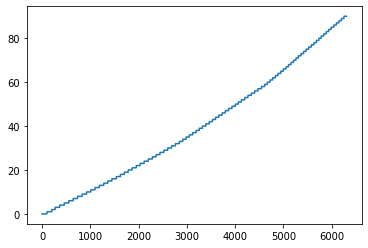

In [129]:
plt.plot(ray)

In [130]:
kick_r.max()

<xarray.DataArray 'kd_kk_x_angle' ()>
array(7.07106781)

In [131]:
kp_.kd_ray_setpoint.max()

<xarray.DataArray 'kd_ray_setpoint' ()>
array(90.)

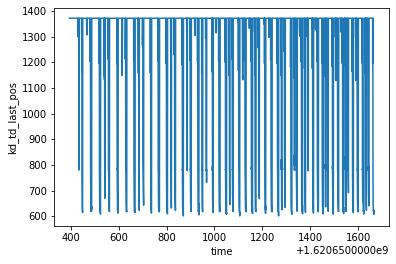

In [132]:
kp_.kd_td_last_pos.plot()

Basically the number of elements in the ring

In [154]:
kp.kd_bm_orbit_x_vec < 30e-3
kp.kd_bm_orbit_y_vec < 30e-3

<xarray.DataArray 'kd_bm_orbit_y_vec' (time: 1807, name: 1372)>
array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]])
Coordinates:
  * time     (time) float64 1.621e+09 1.621e+09 ... 1.621e+09 1.621e+09
  * name     (name) object 'begin' 'dg9l2d1r' ... 'm_fomz1d1r' 'dg9l1d1r'

In [133]:
full_ring = kp_.kd_td_last_pos.max()
full_ring.values

array(1372.)

In [143]:
kp = kp_.isel(time=select)

In [135]:
flags = (kp_.kd_td_last_pos==full_ring) & (kp_.kd_td_loss_plane == 0)

In [136]:
kp = kp_.isel(time=select)

In [137]:
kp_.time.shape, kp.time.shape

((6305,), (1807,))

In [138]:
[name for name in kp.name.values if 'bpm' in name]

['bpmz43d1r',
 'bpmz44d1r',
 'bpmz5d1r',
 'bpmz6d1r',
 'bpmz7d1r',
 'bpmz1t1r',
 'bpmz2t1r',
 'bpmz3t1r',
 'bpmz4t1r',
 'bpmz43t1r',
 'bpmz5t1r',
 'bpmz6t1r',
 'bpmz7t1r',
 'bpmz1d2r',
 'bpmz2d2r',
 'bpmz3d2r',
 'bpmz4d2r',
 'bpmz5d2r',
 'bpmz6d2r',
 'bpmz7d2r',
 'bpmz1t2r',
 'bpmz2t2r',
 'bpmz3t2r',
 'bpmz4t2r',
 'bpmz5t2r',
 'bpmz6t2r',
 'bpmz7t2r',
 'bpmz1d3r',
 'bpmz2d3r',
 'bpmz3d3r',
 'bpmz4d3r',
 'bpmz5d3r',
 'bpmz6d3r',
 'bpmz7d3r',
 'bpmz1t3r',
 'bpmz2t3r',
 'bpmz3t3r',
 'bpmz4t3r',
 'bpmz41t3r',
 'bpmz42t3r',
 'bpmz5t3r',
 'bpmz6t3r',
 'bpmz7t3r',
 'bpmz1d4r',
 'bpmz2d4r',
 'bpmz3d4r',
 'bpmz4d4r',
 'bpmz5d4r',
 'bpmz6d4r',
 'bpmz7d4r',
 'bpmz1t4r',
 'bpmz2t4r',
 'bpmz3t4r',
 'bpmz4t4r',
 'bpmz5t4r',
 'bpmz6t4r',
 'bpmz7t4r',
 'bpmz1d5r',
 'bpmz2d5r',
 'bpmz3d5r',
 'bpmz4d5r',
 'bpmz5d5r',
 'bpmz6d5r',
 'bpmz7d5r',
 'bpmz1t5r',
 'bpmz2t5r',
 'bpmz3t5r',
 'bpmz4t5r',
 'bpmz5t5r',
 'bpmz6t5r',
 'bpmz7t5r',
 'bpmz1d6r',
 'bpmz2d6r',
 'bpmz3d6r',
 'bpmz4d6r',
 'bpmz41d6r',
 'bpmz

In [139]:
for name, zpos in zip(kp.name.values, kp.zpos.values):
    print(f'{name:10s}, {zpos:8.3f}')

begin     ,    0.000
dg9l2d1r  ,    0.616
m_fomz2d1r,    0.616
df9l2d1r  ,    1.137
de9l2d1r  ,    1.785
bpmz43d1r ,    1.785
dd9l2d1r  ,    2.188
bpmz44d1r ,    2.188
db9l2d1r  ,    2.736
bpmz5d1r  ,    2.736
da9l2d1r  ,    2.806
s4m2d1rl  ,    2.886
hs4m2d1r  ,    2.886
s4m2d1rr  ,    2.966
d08l2d1r  ,    3.119
q4m2d1r   ,    3.619
d07l2d1r  ,    3.772
s3m2d1rl  ,    3.852
vs3m2d1r  ,    3.852
s3m2d1rr  ,    3.932
db6l2d1r  ,    3.995
bpmz6d1r  ,    3.995
da6l2d1r  ,    4.085
q3m2d1r   ,    4.335
d05l2d1r  ,    4.755
bm2d1r11  ,    4.907
m_beamport_22,    4.907
bm2d1r12  ,    5.183
hbm2d1r   ,    5.183
bm2d1r2   ,    5.610
d04l2d1r_1,    5.870
blm_q2m2d1r,    5.870
d04l2d1r_2,    6.030
q2m2d1r   ,    6.230
db3l2d1r  ,    6.474
bpmz7d1r  ,    6.474
da3l2d1r  ,    6.537
s2m2d1rl  ,    6.617
vs2m2d1r  ,    6.617
s2m2d1rr  ,    6.697
d02l2d1r  ,    6.985
q1m2d1r   ,    7.235
d01l2d1r_1,    7.340
blm_s1mt1r_1,    7.340
d01l2d1r_2,    7.395
blm_s1mt1r,    7.395
s1mt1rl   ,    7.500
hs1mt1r

In [144]:
libera_bpm_name = 'bpmz42d1r'

In [145]:
reduced = kp.sel(name=libera_bpm_name)

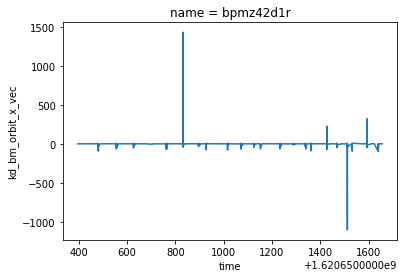

In [146]:
(reduced.kd_bm_orbit_x_vec*1000).plot()

Text(0, 0.5, 'y [mm]')

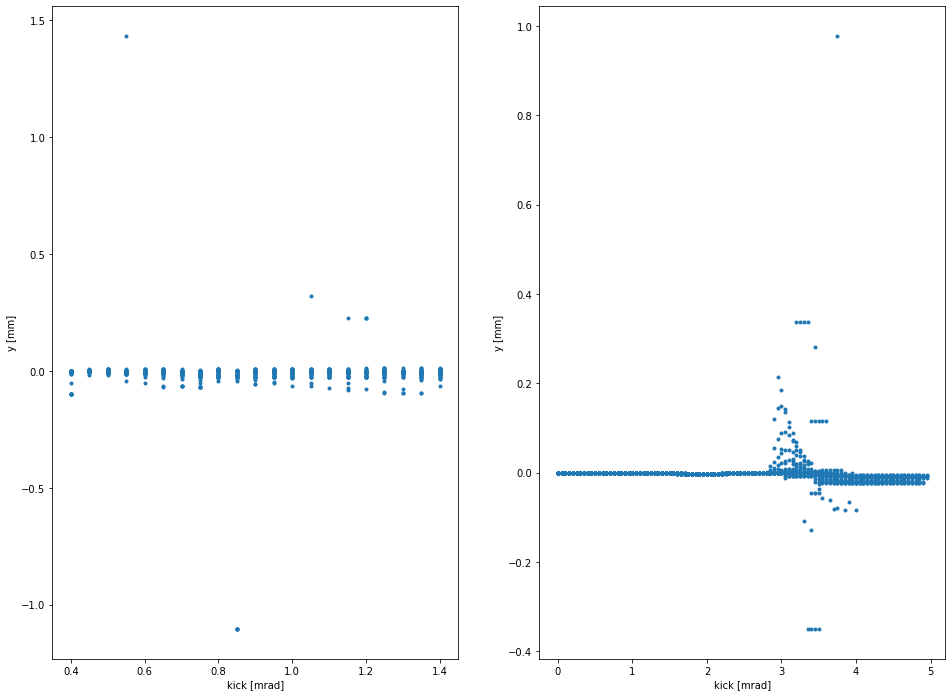

In [152]:
fig, axes = plt.subplots(1, 2, figsize=[16, 12])
ax_x, ax_y = axes
ax_x.plot(reduced.kd_kk_x_angle, reduced.kd_bm_orbit_x_vec, '.')
ax_y.plot(reduced.kd_kk_y_angle, reduced.kd_bm_orbit_y_vec, '.')
ax_x.set_xlabel('kick [mrad]')
ax_x.set_ylabel('y [mm]')
ax_y.set_xlabel('kick [mrad]')
ax_y.set_ylabel('y [mm]')

In [120]:
reduced.kd_k

AttributeError: 'Dataset' object has no attribute 'kd_k'

In [41]:
X_ap, Y_ap = np.meshgrid(
    np.linspace(reduced.kd_kk_a.min(), reduced.kd_kk_x.max()),
    np.linspace(reduced.kd_kk_y.min(), reduced.kd_kk_y.max()),
)

AttributeError: 'Dataset' object has no attribute 'kd_kk_x'

In [ ]:
X = np.array([reduced.kd_kk_x, reduced.kd_kk_y])


In [ ]:
dep = reduced.kd_bm_orbit_x
lg = LinearRegression()
lg.fit(X.T, dep)
angle_x = lg.coef_

angle_x_pp = lg.predict(
    np.array([X_ap.ravel(), Y_ap.ravel()]).T
).reshape(X_p.shape)

In [ ]:
fig = plt.figure(figsize=[16, 12])
ax = Axes3D(fig, #auto_add_to_figure=False
            #azim=180, elev=15
            azim=45, elev=0
           )
ax.plot_wireframe(X_ap*1000, Y_ap*1000, angle_x_pp*1000)
c = ax.scatter3D(reduced.kd_kk_x * 1000,  reduced.kd_kk_y * 1000, reduced.kd_bm_orbit_x * 1000)
ax.set_xlabel(r'$k_x$ [$\mu$rad]', size='large')
ax.set_xlabel(r'$k_y$ [$\mu$rad]', size='large')
ax.set_zlabel('$d_y$')
fig.add_axes(ax)
cax = plt.axes([0.9, 0.2, 0.01, 0.6])
fig.colorbar(c, cax=cax, extend='both')

In [ ]:
dep = reduced.kd_bm_orbit_y
lg = LinearRegression()
lg.fit(X.T, dep)
angle_y = lg.coef_

angle_y_pp = lg.predict(
    np.array([X_ap.ravel(), Y_ap.ravel()]).T
).reshape(X_p.shape)

In [ ]:
fig = plt.figure(figsize=[16, 12])
ax = Axes3D(fig, #auto_add_to_figure=False
            azim=180, elev=15
            #azim=45, elev=15
           )
ax.plot_wireframe(X_ap * 1000, Y_ap * 1000, angle_y_pp * 1000)
c = ax.scatter3D(reduced.kd_kk_x * 1000,  reduced.kd_kk_y * 1000, reduced.kd_bm_orbit_y * 1000)
ax.set_xlabel(r'$k_x$ [$\mu$rad]', size='large')
ax.set_xlabel(r'$k_y$ [$\mu$rad]', size='large')
ax.set_zlabel('$d_y$')
fig.add_axes(ax)
cax = plt.axes([0.9, 0.2, 0.01, 0.6])
fig.colorbar(c, cax=cax, extend='both')

In [ ]:
kick_x

In [ ]:
kick_y

In [ ]:
angle_x

In [ ]:
angle_y



# Now down to the math

$$
    \Delta x = k_x V_x
$$

$$
    \Delta x = g_x \alpha_x
$$

Thus 

$$
     \alpha_x = 
     \underbrace{\frac{k_x}{g_x}}_{r_x}
     V_x
$$


here
* $k_x$: kick_x
* $g_x$: angle_x

In [ ]:
r_x_all = kick_x / angle_x
r_x_all

In [ ]:
r_y_all = kick_y / angle_y
r_y_all

In [ ]:
r_x = r_x_all[0]
r_y = r_y_all[1]
r_x, r_y

In [ ]:
## Same in k_x, k_y

## Dynamic aperture estimate

In [ ]:
fig = plt.figure(figsize=[16, 12])
ax = Axes3D(fig, #auto_add_to_figure=False
            azim=180, elev=15
            #azim=45, elev=15
           )
c = ax.scatter3D(x_p * r_x, y_p * r_y, kick_y_p, c=current, vmin=0, vmax=1.5)

In [ ]:
select = (kp_.kd_td_stat_cod.astype(bool))
kp_plt = kp_.isel(time=select)

In [ ]:
red_plt = kp_plt.sel(name=libera_bpm_name)

In [ ]:
pr_x = r_x #/ 2
pr_y = r_y #/ 2

In [ ]:
fig, axes = plt.subplots(2, 2, sharex=True, sharey=True, figsize=[16, 12])
ax_meas, ax_calc = axes
ax_x, ax_y = ax_meas
ax_x.scatter(x_p * pr_x, y_p * pr_y, c=kick_x_p)
ax_y.scatter(x_p * pr_x, y_p * pr_y, c=kick_y_p)
ax_x.set_ylabel(r'$\alpha_y$ [$\mu$rad]')

ax_x, ax_y = ax_calc
ax_x.scatter(red_plt.kd_kk_x * 1000,  red_plt.kd_kk_y * 1000, c=red_plt.kd_bm_orbit_x * 1000)
ax_y.scatter(red_plt.kd_kk_x * 1000,  red_plt.kd_kk_y * 1000, c=red_plt.kd_bm_orbit_y * 1000)
ax_x.set_ylabel(r'$\alpha_y$ [$\mu$rad]')
ax_x.set_xlabel(r'$\alpha_x$ [$\mu$rad]')
ax_y.set_xlabel(r'$\alpha_x$ [$\mu$rad]')
